# INSURANCCE

## Studying the data



In [1]:

medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [2]:
from urllib.request import urlretrieve
urlretrieve(medical_charges_url, 'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x1d2b881a350>)

In [3]:
!pip install pandas --quiet
import pandas as pd

In [4]:
medical_df = pd.read_csv('medical.csv')
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
!pip install plotly matplotlib seaborn --quiet
!pip install nbformat --quiet


In [8]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.io as pio
%matplotlib inline

In [9]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [10]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [11]:
fig = px.histogram(medical_df, 
                   x='age', 
                   marginal='box', 
                   
                   
                   nbins=47, 
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
pio.renderers.default = "vscode"

fig.show()

In [12]:
fig = px.histogram(medical_df,
                   x = 'bmi',
                   marginal = 'box',
                   color_discrete_sequence=["red"],
                   title="distribution of BMI ")
fig.update_layout(bargap = 0.5)
pio.renderers.default = "vscode"
fig.show()


In [13]:
fig = px.histogram(medical_df,
                   x="charges", 
                   color = "smoker",
                   marginal = "box",
                   color_discrete_sequence=["yellow", "orange"],
                   title="annual medical charges")
fig.update_layout(bargap=0.2)
pio.renderers.default="vscode"
fig.show()

In [14]:
fig = px.scatter(medical_df, 
                 x='age', 
                 y='charges', 
                 color='smoker', 
                 opacity=1, 
                 hover_data=['sex'], 
                 title='Age vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

In [15]:
fig = px.scatter(medical_df, 
                 x='bmi', 
                 y='charges', 
                 color='smoker', 
                 opacity=0.8, 
                 hover_data=['sex'], 
                 title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

## Correlation Coefficient

In [16]:
print("age and charges: ", medical_df.charges.corr(medical_df.age))
print("bmi and charges: ", medical_df.charges.corr(medical_df.bmi))
smoker_values = {"no": 0, "yes": 1}
smoker_numerical = medical_df.smoker.map(smoker_values)
print("smoker and charges: ", medical_df.charges.corr(smoker_numerical))

age and charges:  0.2990081933306476
bmi and charges:  0.19834096883362878
smoker and charges:  0.7872514304984782


## Linear Regression using a Single Feature

<Axes: title={'center': 'Age vs. Charges'}, xlabel='age', ylabel='charges'>

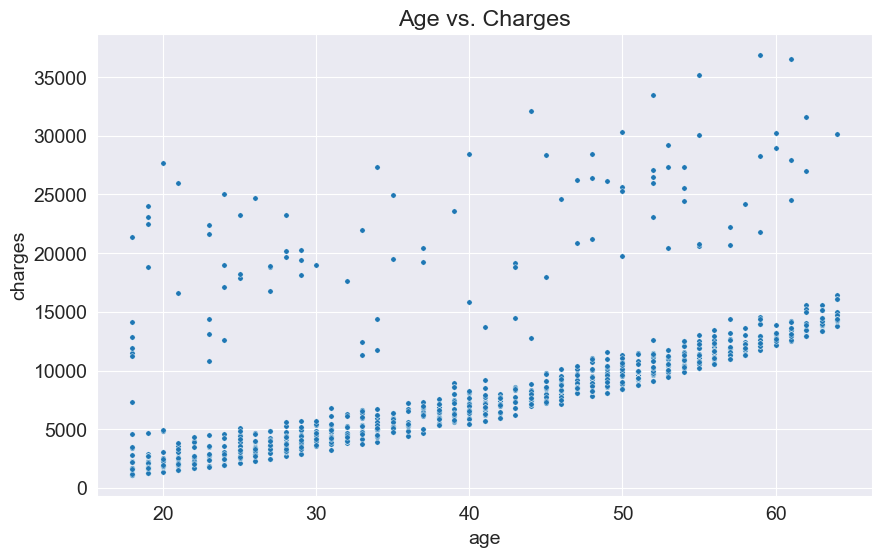

In [17]:
non_smoker_df = medical_df[medical_df.smoker == 'no']
plt.title('Age vs. Charges')
sns.scatterplot(data=non_smoker_df, x='age', y='charges', alpha=1, s=15
                )

### MODEL

Text(0, 0.5, 'charges')

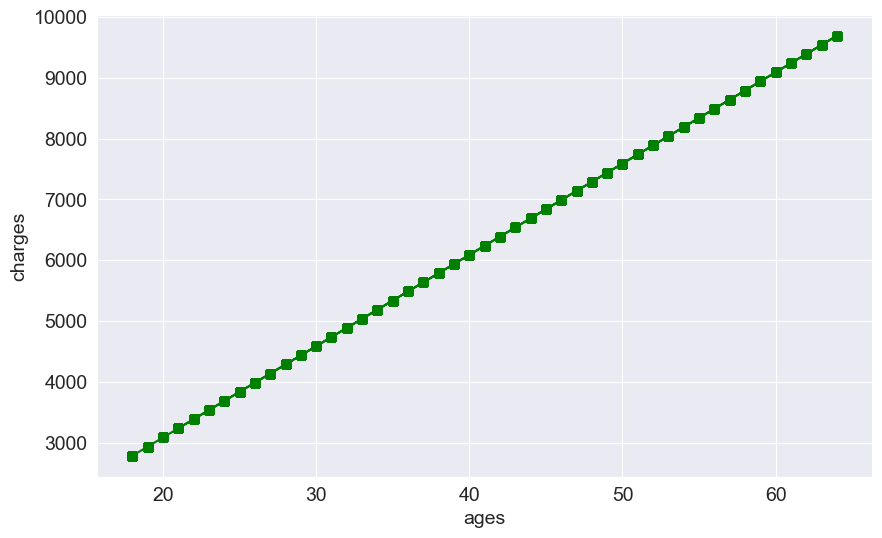

In [18]:
def estimate_charge(age, w, b):
    return w*age + b
ages = non_smoker_df.age
w,b = 150, 90
estimate_charges = estimate_charge(ages, w, b) 
plt.plot(ages, estimate_charges , "g-s")
plt.xlabel("ages")
plt.ylabel("charges")

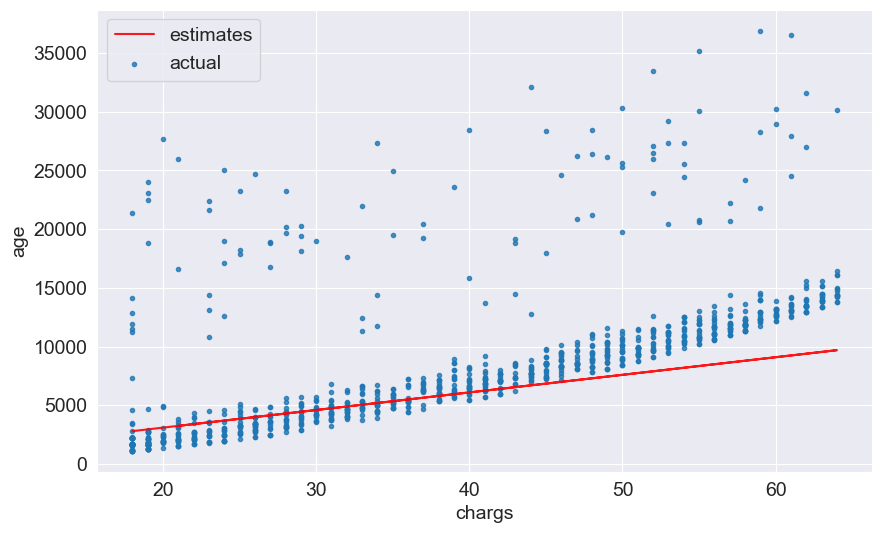

In [19]:
target = non_smoker_df.charges
plt.plot(ages, estimate_charges , "r", alpha = 0.9)
plt.scatter(ages, target, s = 9 , alpha = 0.8)
plt.xlabel("chargs")
plt.ylabel("age")
plt.legend(["estimates", "actual"])

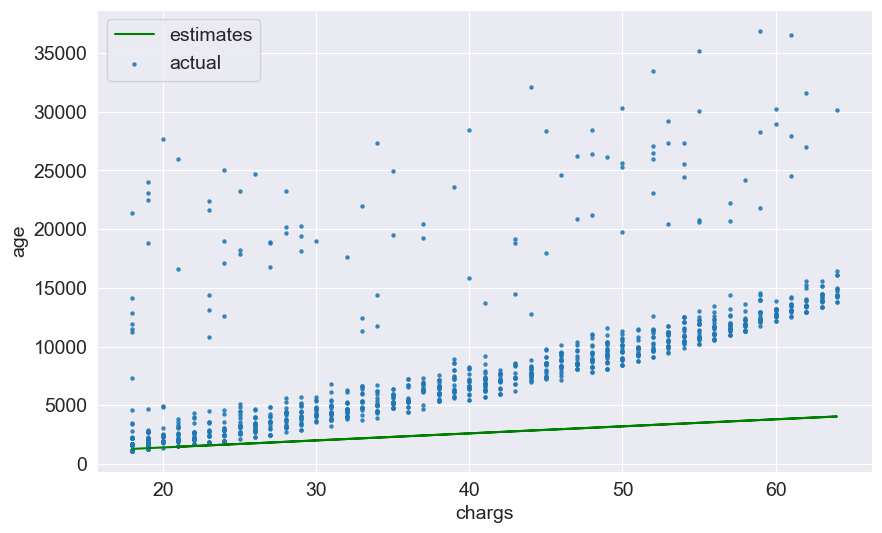

In [20]:
def try_parameter(w, b):
    ages = non_smoker_df.age
    charges = non_smoker_df.charges
    estimate_charges = estimate_charge(ages, w, b)
    plt.plot(ages, estimate_charges, "g", alpha = 1)
    plt.scatter(ages, charges, s = 5, alpha = 0.8)
    plt.xlabel("chargs")
    plt.ylabel("age")
    plt.legend(["estimates", "actual"])
try_parameter(60, 200)
    

### LOst and cost


In [21]:

!pip install numpy --quiet
import numpy as np
def rmse(target, prediction):
    return np.sqrt(np.mean(np.square(target - prediction)))

In [22]:
target = non_smoker_df.charges
ages = non_smoker_df.age
prediction = estimate_charge(ages , 150, 90)
print(rmse(target, prediction))

5513.569257372077


### Linear regression using Sckit learning 

In [23]:
!pip install scikit-learn --quiet

In [24]:
from sklearn.linear_model import LinearRegression
model = LinearRegression() # creating model oblject


In [25]:
input = non_smoker_df[["age"]]
# input = non_smoker_df.age
target = non_smoker_df.charges
model.fit(input, target)
model.predict(pd.DataFrame([[29], [35], [67]], columns=["age"]))

array([ 5658.79791554,  7262.29139253, 15814.25660313])

[2719.0598744  5391.54900271 6727.79356686 ... 2719.0598744  2719.0598744
 3520.80661289]


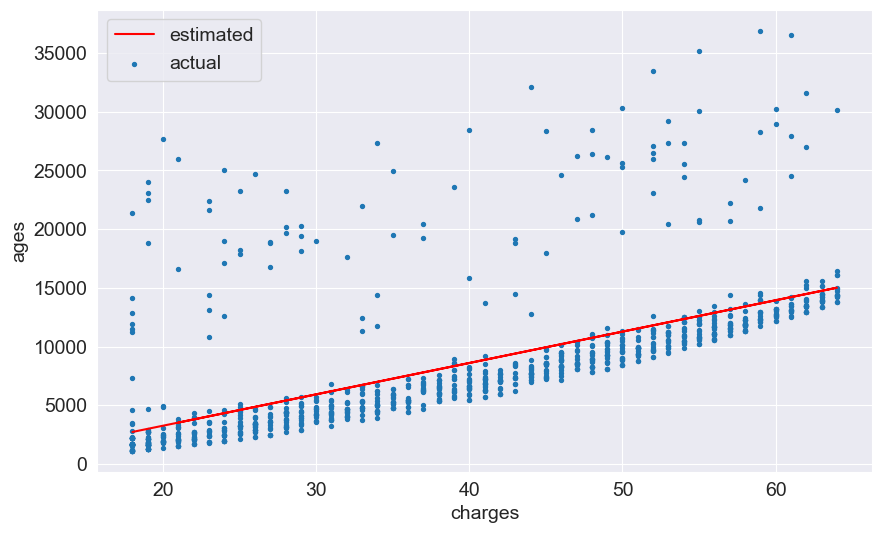

In [26]:
prediction = model.predict(input)
print(prediction)
plt.plot(input, prediction, "r")
plt.scatter(input, target, s = 8)
plt.xlabel("charges")
plt.ylabel("ages")
plt.legend(["estimated", "actual"])

4662.505766636395
[267.24891283]
-2091.4205565650864


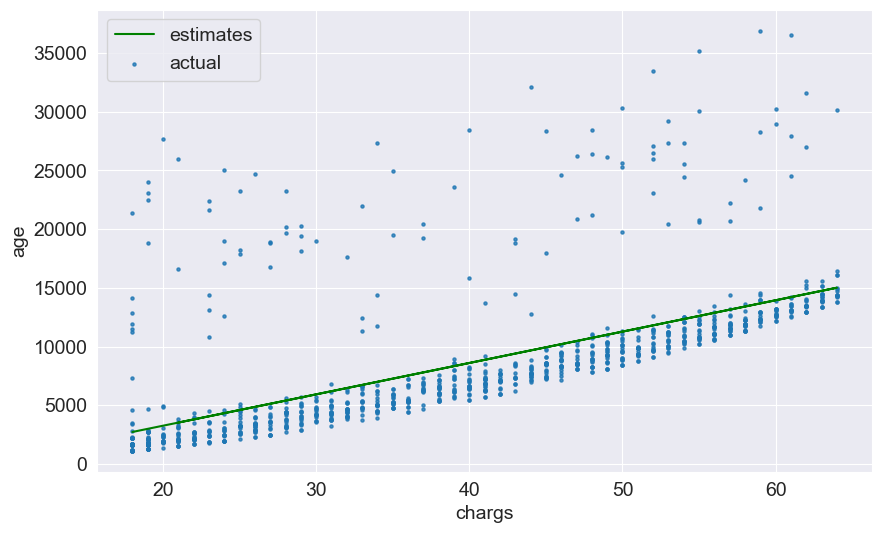

In [27]:
print(rmse(target, prediction))
print(model.coef_)
print(model.intercept_)
try_parameter(model.coef_, model.intercept_)

### SGDReggressor


In [28]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

X = non_smoker_df[["age"]]   
y = non_smoker_df["charges"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


model = SGDRegressor(
    max_iter=1000,
    tol=1e-3,
    penalty='l2',
    alpha=0.0001,
    learning_rate='invscaling',
    eta0=0.01,
    random_state=42
)

model.fit(X_scaled, y)

new_ages = pd.DataFrame([[29], [35], [67]], columns=["age"])
new_ages_scaled = scaler.transform(new_ages)
predictions = model.predict(new_ages_scaled)

print(predictions)


[ 5628.70718456  7241.6169951  15843.80265133]


C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



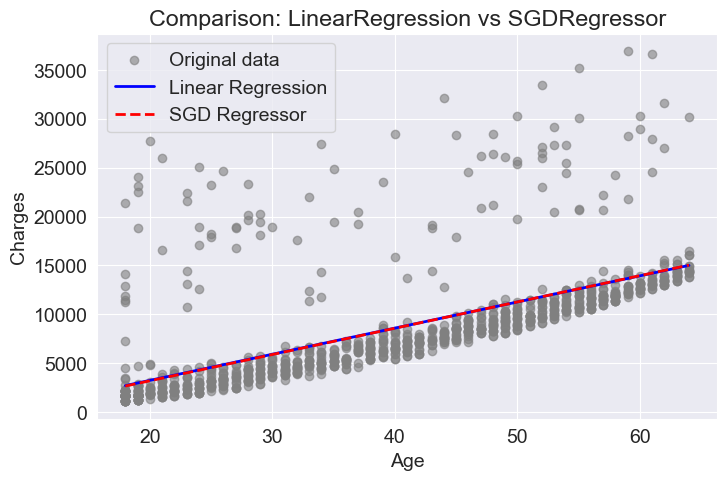

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler

# === Step 1: Prepare data (your existing setup) ===
X = non_smoker_df[["age"]]
y = non_smoker_df["charges"]

# === Step 2: Linear Regression model ===
lin_model = LinearRegression()
lin_model.fit(X, y)

# === Step 3: SGD Regressor (with scaling) ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sgd_model = SGDRegressor(
    max_iter=1000,
    tol=1e-3,
    penalty='l2',
    alpha=0.0001,
    learning_rate='invscaling',
    eta0=0.01,
    random_state=42
)
sgd_model.fit(X_scaled, y)

# === Step 4: Prepare data for plotting ===
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
lin_preds = lin_model.predict(X_range)
sgd_preds = sgd_model.predict(scaler.transform(X_range))

# === Step 5: Plot ===
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='gray', alpha=0.6, label='Original data')
plt.plot(X_range, lin_preds, color='blue', linewidth=2, label='Linear Regression')
plt.plot(X_range, sgd_preds, color='red', linestyle='--', linewidth=2, label='SGD Regressor')

plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Comparison: LinearRegression vs SGDRegressor")
plt.legend()
plt.grid(True)
plt.show()



## Linear regression on multiple features

In [32]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children']], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 11355.317901125973


### Using the binary catergories also (smoker and non smoker)

In [38]:
smoker_codes = {"no" : 0, "yes":1}
medical_df["smoker_codes"] = medical_df.smoker.map(smoker_codes)
print(medical_df.charges.corr(medical_df.smoker_codes))
sex_codes = {"female":1, "male":2}
medical_df["sex"] = medical_df.sex.map(sex_codes)
print(medical_df.charges.corr(medical_df.sex))

medical_df

0.7872514304984782
0.05729206220202531


,age,sex,bmi,children,smoker,region,charges,smoker_codes
0,19,1,27.900,0,yes,southwest,16884.92400,1
1,18,2,33.770,1,no,southeast,1725.55230,0
2,28,2,33.000,3,no,southeast,4449.46200,0
3,33,2,22.705,0,no,northwest,21984.47061,0
4,32,2,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,2,30.970,3,no,northwest,10600.54830,0
1334,18,1,31.920,0,no,northeast,2205.98080,0
1335,18,1,36.850,0,no,southeast,1629.83350,0
1336,21,1,25.800,0,no,southwest,2007.94500,0


In [47]:
inputs = medical_df[["age", "sex", "bmi", "smoker_codes", "children"]]
target = medical_df["charges"]
model = LinearRegression().fit(inputs, target)
prediction = model.predict(inputs)
loss = rmse(target, prediction)
print(loss)

6056.100708754546


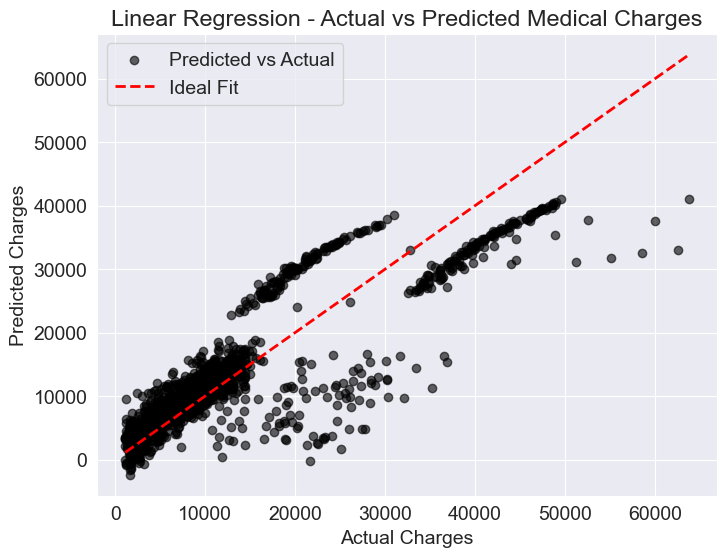

In [49]:
plt.figure(figsize=(8, 6))
plt.scatter(target, prediction, alpha=0.6, color='black', label='Predicted vs Actual')
plt.plot([target.min(), target.max()], [target.min(), target.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Linear Regression - Actual vs Predicted Medical Charges")
plt.legend()
plt.grid(True)
plt.show()

### Hot encoding for region (4 catergories )

In [50]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [51]:
one_hot = enc.transform(medical_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]], shape=(1338, 4))

In [52]:
medical_df[['northeast', 'northwest', 'southeast', 'southwest']] = one_hot
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_codes,northeast,northwest,southeast,southwest
0,19,1,27.900,0,yes,southwest,16884.92400,1,0.0,0.0,0.0,1.0
1,18,2,33.770,1,no,southeast,1725.55230,0,0.0,0.0,1.0,0.0
2,28,2,33.000,3,no,southeast,4449.46200,0,0.0,0.0,1.0,0.0
3,33,2,22.705,0,no,northwest,21984.47061,0,0.0,1.0,0.0,0.0
4,32,2,28.880,0,no,northwest,3866.85520,0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,2,30.970,3,no,northwest,10600.54830,0,0.0,1.0,0.0,0.0
1334,18,1,31.920,0,no,northeast,2205.98080,0,1.0,0.0,0.0,0.0
1335,18,1,36.850,0,no,southeast,1629.83350,0,0.0,0.0,1.0,0.0
1336,21,1,25.800,0,no,southwest,2007.94500,0,0.0,0.0,0.0,1.0


In [ ]:

input_cols = ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'smoker_codes', 'northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = medical_df[input_cols], medical_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

ValueError: could not convert string to float: 'yes'

In [54]:
medical_df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'smoker_codes', 'northeast', 'northwest', 'southeast', 'southwest'],
      dtype='object')